## HW6: Dimensionality Reduction: PCA, Kernel PCA, t-SNE, and UMAP

In this lab, we compare different dimensionality reduction methods and evaluate them.

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


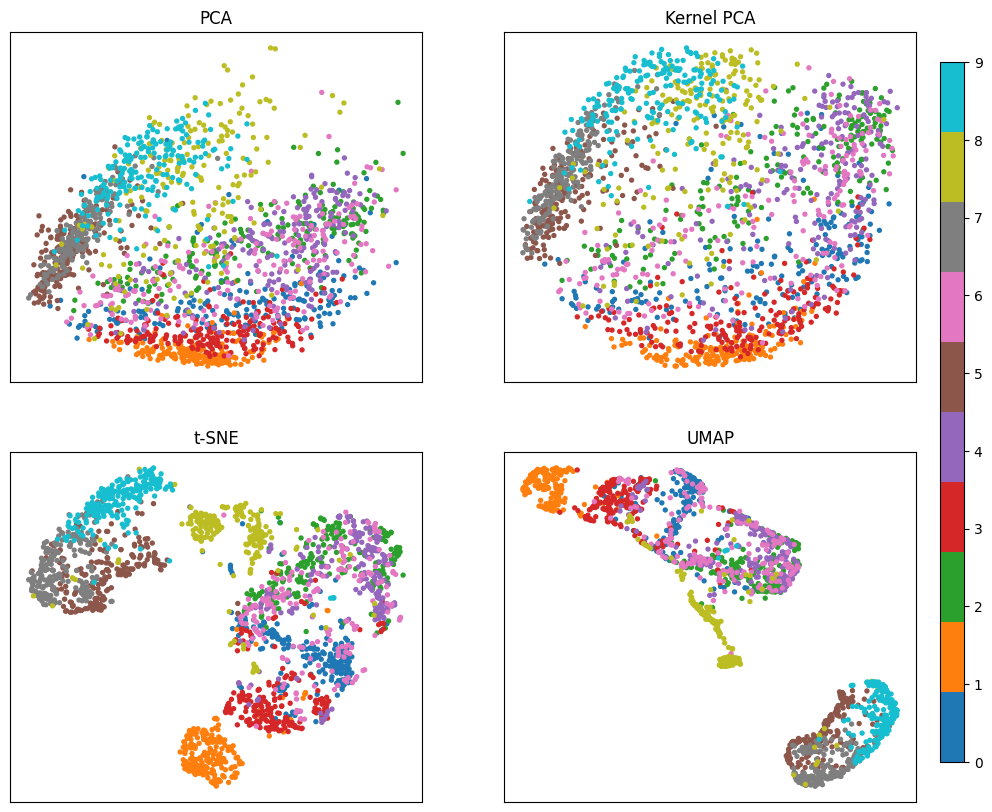

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE
import umap

# --------------------------------------------------
# Load dataset
# --------------------------------------------------
X, y = fetch_openml("Fashion-MNIST", version=1, return_X_y=True)

X = X.to_numpy().astype(float)
y = y.astype(int)

# ------------------------------------------------
# Balanced sampling (200 per class → 2000 points)
# ------------------------------------------------
np.random.seed(0)

indices = []
for c in range(10):
    class_idx = np.where(y == c)[0]
    indices.extend(np.random.choice(class_idx, 200, replace=False))

indices = np.array(indices)

X = X[indices]
y = y[indices]


# --------------------------------------------------
# Standardize data
# --------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --------------------------------------------------
# PCA (2D embedding)
# --------------------------------------------------
pca2 = PCA(n_components=2)
Z_pca = pca2.fit_transform(X_scaled)

# --------------------------------------------------
# Kernel PCA
# --------------------------------------------------
kpca = KernelPCA(n_components=2, kernel="rbf", gamma=0.0005)
Z_kpca = kpca.fit_transform(X_scaled)

# --------------------------------------------------
# PCA preprocessing for nonlinear methods
# --------------------------------------------------
pca50 = PCA(n_components=50)
X_pca50 = pca50.fit_transform(X_scaled)

# --------------------------------------------------
# t-SNE
# --------------------------------------------------
tsne = TSNE(
    n_components=2,
    perplexity=50,
    init="pca",
    learning_rate="auto",
    random_state=0
)

Z_tsne = tsne.fit_transform(X_pca50)

# --------------------------------------------------
# UMAP
# --------------------------------------------------
umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=0
)

Z_umap = umap_model.fit_transform(X_pca50)

# --------------------------------------------------
# Panel plot (2x2)
# --------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12,10))

plots = [
    (Z_pca, "PCA"),
    (Z_kpca, "Kernel PCA"),
    (Z_tsne, "t-SNE"),
    (Z_umap, "UMAP")
]

for ax, (Z, title) in zip(axes.ravel(), plots):
    sc = ax.scatter(Z[:,0], Z[:,1], c=y, cmap="tab10", s=8)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

# add space on the right for colorbar
fig.subplots_adjust(right=0.88)

# dedicated colorbar axis
cbar_ax = fig.add_axes([0.9, 0.15, 0.02, 0.7])
fig.colorbar(sc, cax=cbar_ax)

plt.show()

In [6]:
from pathlib import Path
from itertools import product
from time import perf_counter

import pandas as pd
from sklearn.manifold import trustworthiness

FIG_DIR = Path("figs_results")
FIG_DIR.mkdir(exist_ok=True)

STUDENT_TAG = "senthilnathan_t"
TASK_TAG = "a6_task1"

figure_counter = 1
saved_figures = []
tsne_label_to_params = {}
umap_label_to_params = {}


def next_figure_path(label):
    global figure_counter
    filename = f"{TASK_TAG}_fig{figure_counter:02d}_{STUDENT_TAG}_{label}.png"
    figure_counter += 1
    path = FIG_DIR / filename
    saved_figures.append(path.name)
    return path


def scatter_embedding(Z, labels, title, ax, s=10):
    sc = ax.scatter(Z[:, 0], Z[:, 1], c=labels, cmap="tab10", s=s)
    ax.set_title(title)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    return sc


def save_grid_figure(embeddings, labels, titles, layout, figure_title, save_label, figsize, s=10):
    rows, cols = layout
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()
    last_scatter = None

    for ax, embedding, title in zip(axes, embeddings, titles):
        last_scatter = scatter_embedding(embedding, labels, title, ax=ax, s=s)

    for ax in axes[len(embeddings):]:
        ax.axis("off")

    fig.suptitle(figure_title, fontsize=14)
    fig.tight_layout(rect=[0, 0, 0.94, 0.97])
    cbar_ax = fig.add_axes([0.96, 0.15, 0.015, 0.7])
    cbar = fig.colorbar(last_scatter, cax=cbar_ax)
    cbar.set_label("Class label")
    path = next_figure_path(save_label)
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    return path


def embedding_summary(name, params, embedding, input_data):
    return {
        "method": name,
        "params": params,
        "trustworthiness": trustworthiness(input_data, embedding, n_neighbors=15),
    }


def timed_run(run_fn, repeats=3):
    times = []
    result = None
    for _ in range(repeats):
        start = perf_counter()
        result = run_fn()
        times.append(perf_counter() - start)
    return result, times


FIG_DIR.resolve()

PosixPath('/Users/tsn/github-classroom/ma5755-datavisual-iitm/hw6-Senthilnathan-03/figs_results')

Running t-SNE with perp_10_lr_50...
Running t-SNE with perp_10_lr_100...
Running t-SNE with perp_10_lr_500...
Running t-SNE with perp_30_lr_50...
Running t-SNE with perp_30_lr_100...
Running t-SNE with perp_30_lr_500...
Running t-SNE with perp_50_lr_50...
Running t-SNE with perp_50_lr_100...
Running t-SNE with perp_50_lr_500...


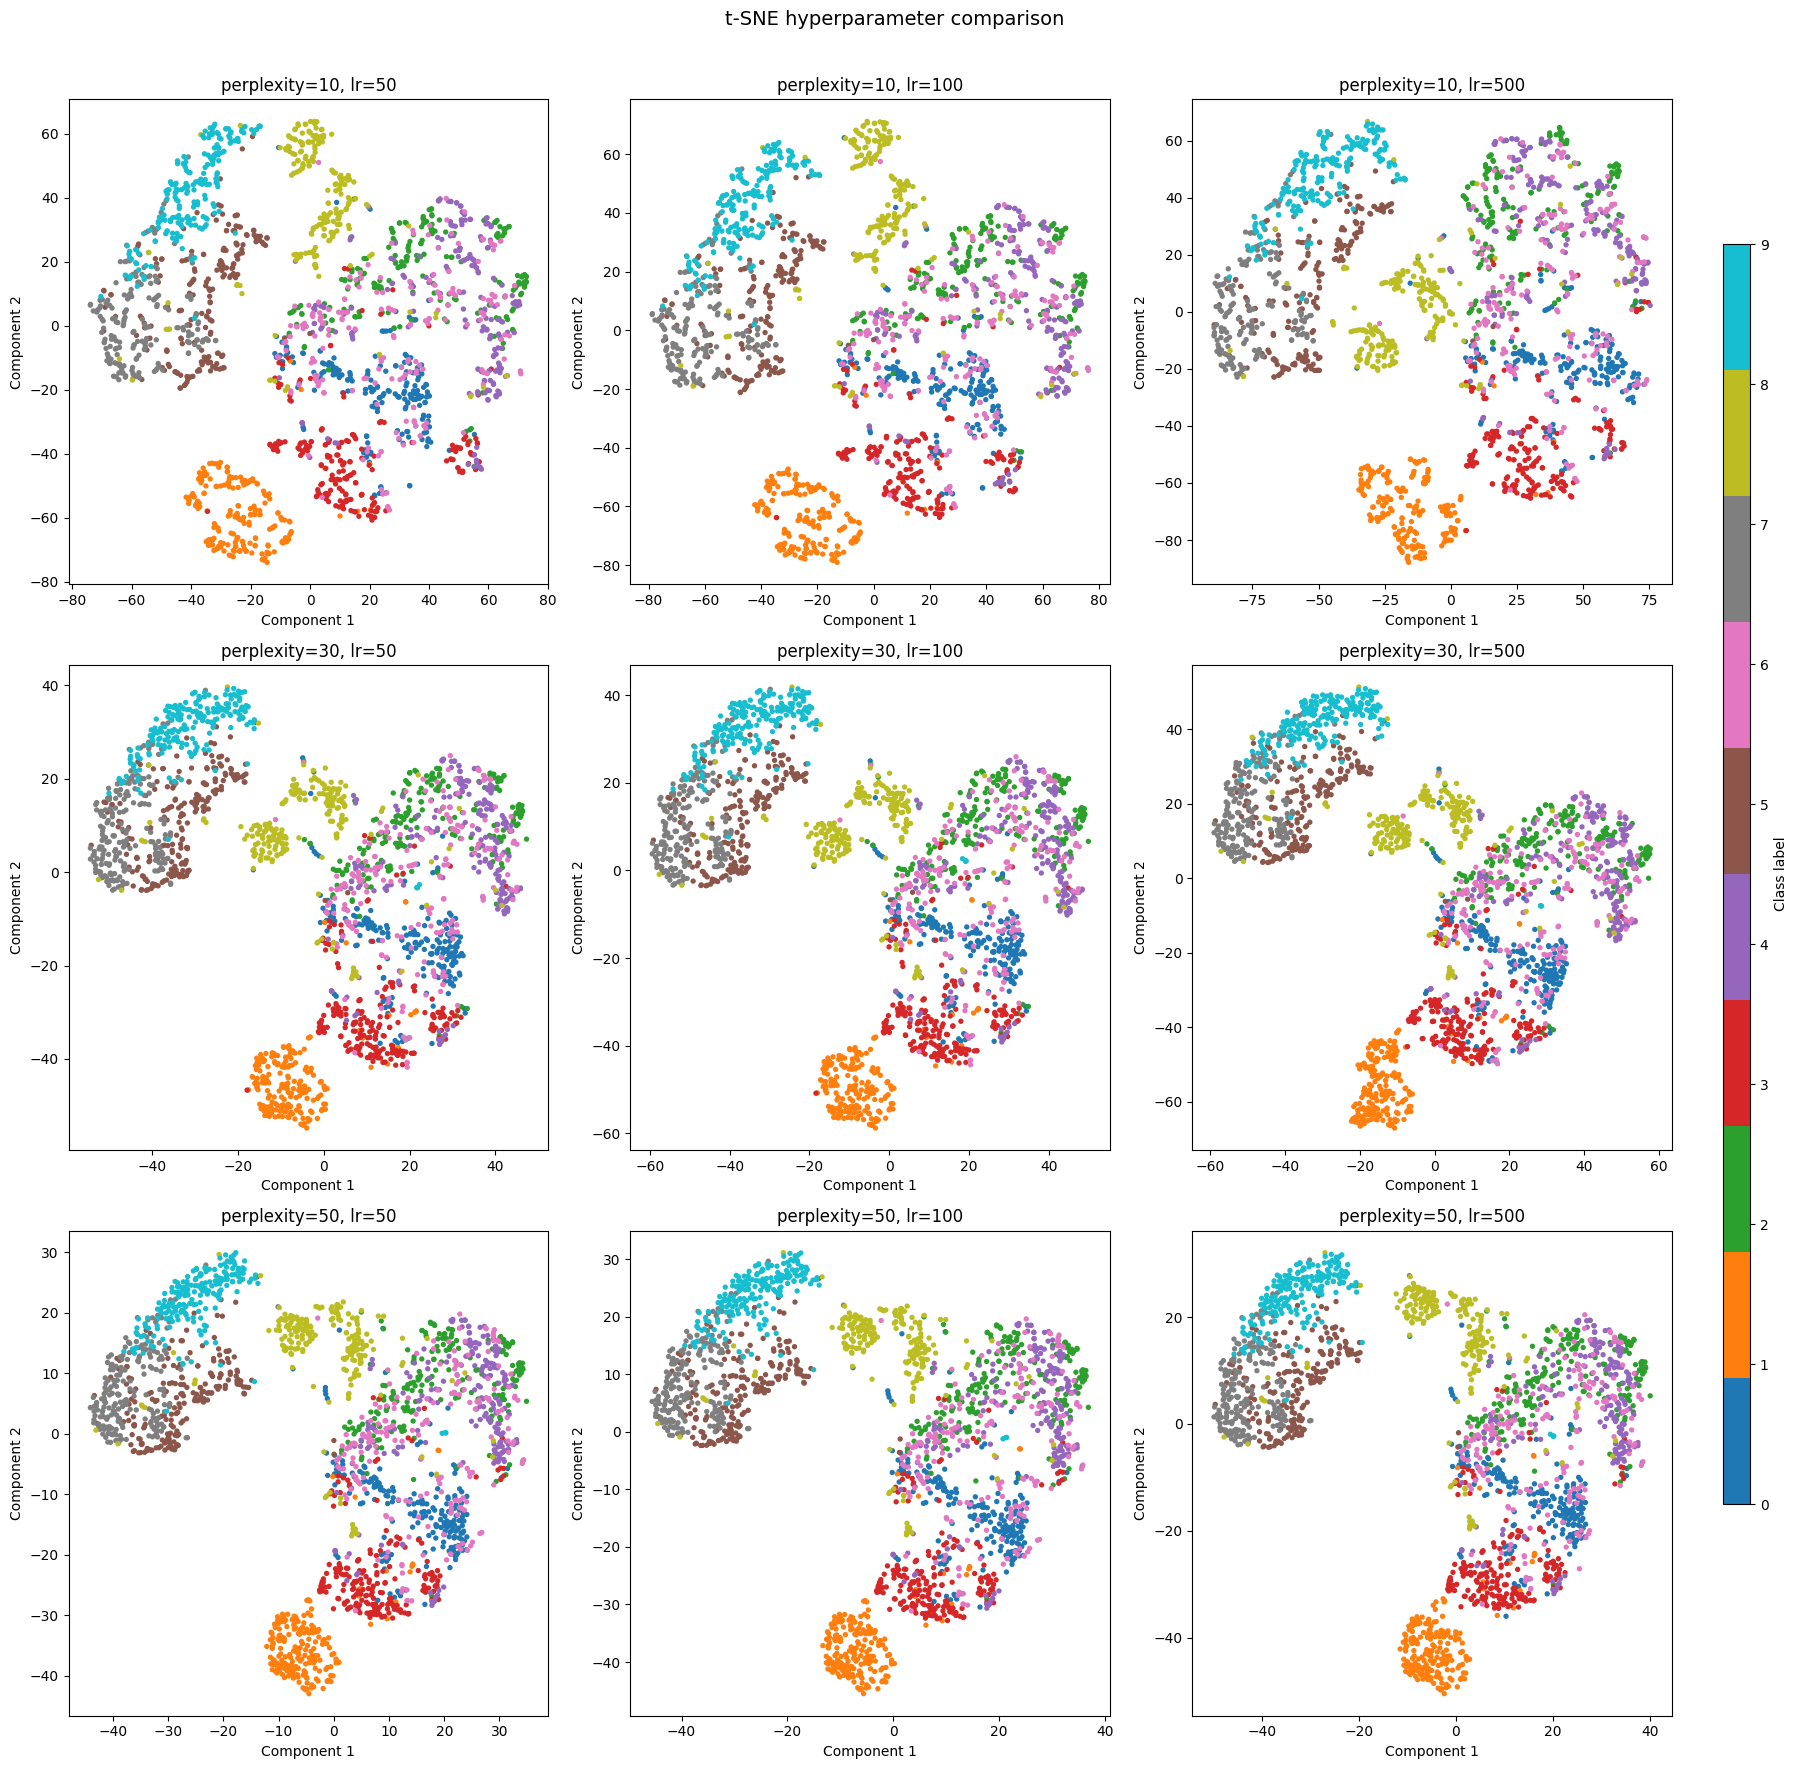

Saved t-SNE grid to figs_results/a6_task1_fig01_senthilnathan_t_tsne_grid_comparison.png


,method,params,trustworthiness
6,t-SNE,"{'perplexity': 50, 'learning_rate': 50}",0.981446
7,t-SNE,"{'perplexity': 50, 'learning_rate': 100}",0.980885
3,t-SNE,"{'perplexity': 30, 'learning_rate': 50}",0.980833
5,t-SNE,"{'perplexity': 30, 'learning_rate': 500}",0.980711
4,t-SNE,"{'perplexity': 30, 'learning_rate': 100}",0.980688
8,t-SNE,"{'perplexity': 50, 'learning_rate': 500}",0.980595
1,t-SNE,"{'perplexity': 10, 'learning_rate': 100}",0.979271
0,t-SNE,"{'perplexity': 10, 'learning_rate': 50}",0.979229
2,t-SNE,"{'perplexity': 10, 'learning_rate': 500}",0.978356


In [7]:
# t-SNE hyperparameter sweep shown as a comparison grid.
tsne_grid = list(product([10, 30, 50], [50, 100, 500]))
tsne_results = []
tsne_embeddings = {}
tsne_titles = []

for perplexity, learning_rate in tsne_grid:
    label = f"perp_{perplexity}_lr_{learning_rate}"
    print(f"Running t-SNE with {label}...")
    tsne_model = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate=learning_rate,
        random_state=0,
    )
    Z = tsne_model.fit_transform(X_pca50)
    tsne_embeddings[label] = Z
    tsne_label_to_params[label] = {"perplexity": perplexity, "learning_rate": learning_rate}
    tsne_titles.append(f"perplexity={perplexity}, lr={learning_rate}")
    tsne_results.append(
        embedding_summary(
            "t-SNE",
            {"perplexity": perplexity, "learning_rate": learning_rate},
            Z,
            X_pca50,
        )
    )

tsne_grid_path = save_grid_figure(
    embeddings=[tsne_embeddings[label] for label in tsne_embeddings],
    labels=y,
    titles=tsne_titles,
    layout=(3, 3),
    figure_title="t-SNE hyperparameter comparison",
    save_label="tsne_grid_comparison",
    figsize=(18, 18),
    s=8,
)
print(f"Saved t-SNE grid to {tsne_grid_path}")
tsne_results_df = pd.DataFrame(tsne_results).sort_values("trustworthiness", ascending=False)
tsne_results_df

Running UMAP with nn_5_md_0p1...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Running UMAP with nn_5_md_0p3...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Running UMAP with nn_5_md_0p6...


...

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Running UMAP with nn_30_md_0p3...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Running UMAP with nn_30_md_0p6...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


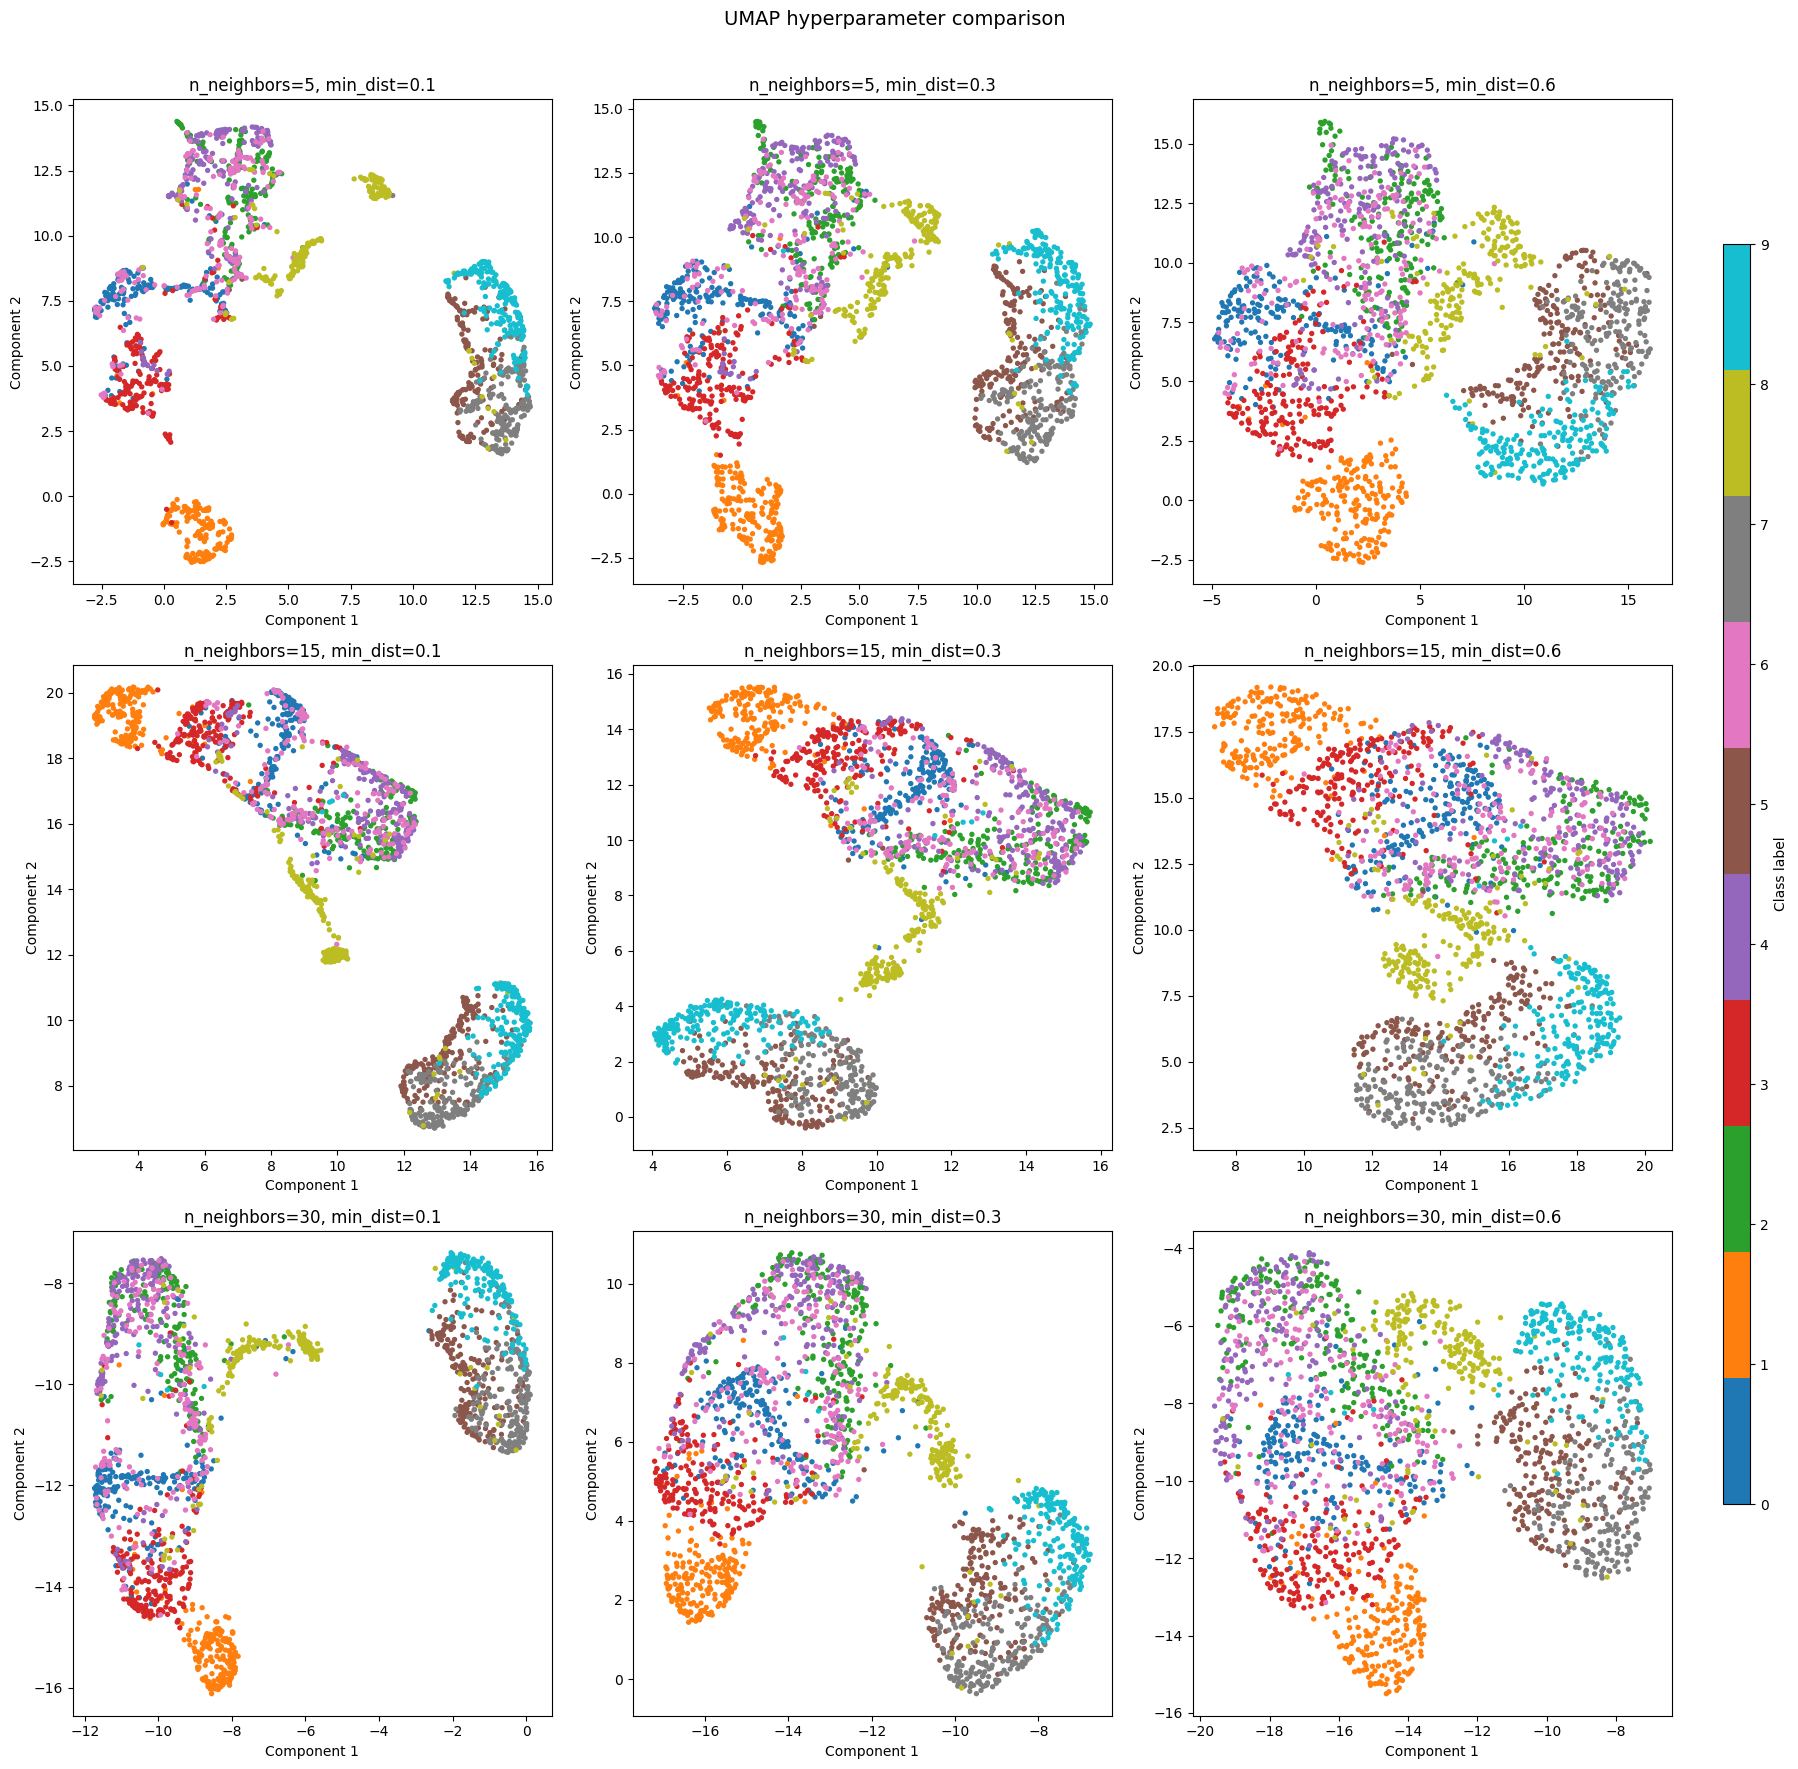

Saved UMAP grid to figs_results/a6_task1_fig02_senthilnathan_t_umap_grid_comparison.png


,method,params,trustworthiness
0,UMAP,"{'n_neighbors': 5, 'min_dist': 0.1}",0.972724
3,UMAP,"{'n_neighbors': 15, 'min_dist': 0.1}",0.971541
1,UMAP,"{'n_neighbors': 5, 'min_dist': 0.3}",0.970468
6,UMAP,"{'n_neighbors': 30, 'min_dist': 0.1}",0.968679
4,UMAP,"{'n_neighbors': 15, 'min_dist': 0.3}",0.965682
7,UMAP,"{'n_neighbors': 30, 'min_dist': 0.3}",0.963240
2,UMAP,"{'n_neighbors': 5, 'min_dist': 0.6}",0.961214
5,UMAP,"{'n_neighbors': 15, 'min_dist': 0.6}",0.954916
8,UMAP,"{'n_neighbors': 30, 'min_dist': 0.6}",0.952914


In [8]:
# UMAP hyperparameter sweep shown as a comparison grid.
umap_grid = list(product([5, 15, 30], [0.1, 0.3, 0.6]))
umap_results = []
umap_embeddings = {}
umap_titles = []

for n_neighbors, min_dist in umap_grid:
    label = f"nn_{n_neighbors}_md_{str(min_dist).replace('.', 'p')}"
    print(f"Running UMAP with {label}...")
    umap_model = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        random_state=0,
    )
    Z = umap_model.fit_transform(X_pca50)
    umap_embeddings[label] = Z
    umap_label_to_params[label] = {"n_neighbors": n_neighbors, "min_dist": min_dist}
    umap_titles.append(f"n_neighbors={n_neighbors}, min_dist={min_dist}")
    umap_results.append(
        embedding_summary(
            "UMAP",
            {"n_neighbors": n_neighbors, "min_dist": min_dist},
            Z,
            X_pca50,
        )
    )

umap_grid_path = save_grid_figure(
    embeddings=[umap_embeddings[label] for label in umap_embeddings],
    labels=y,
    titles=umap_titles,
    layout=(3, 3),
    figure_title="UMAP hyperparameter comparison",
    save_label="umap_grid_comparison",
    figsize=(18, 18),
    s=8,
)
print(f"Saved UMAP grid to {umap_grid_path}")
umap_results_df = pd.DataFrame(umap_results).sort_values("trustworthiness", ascending=False)
umap_results_df

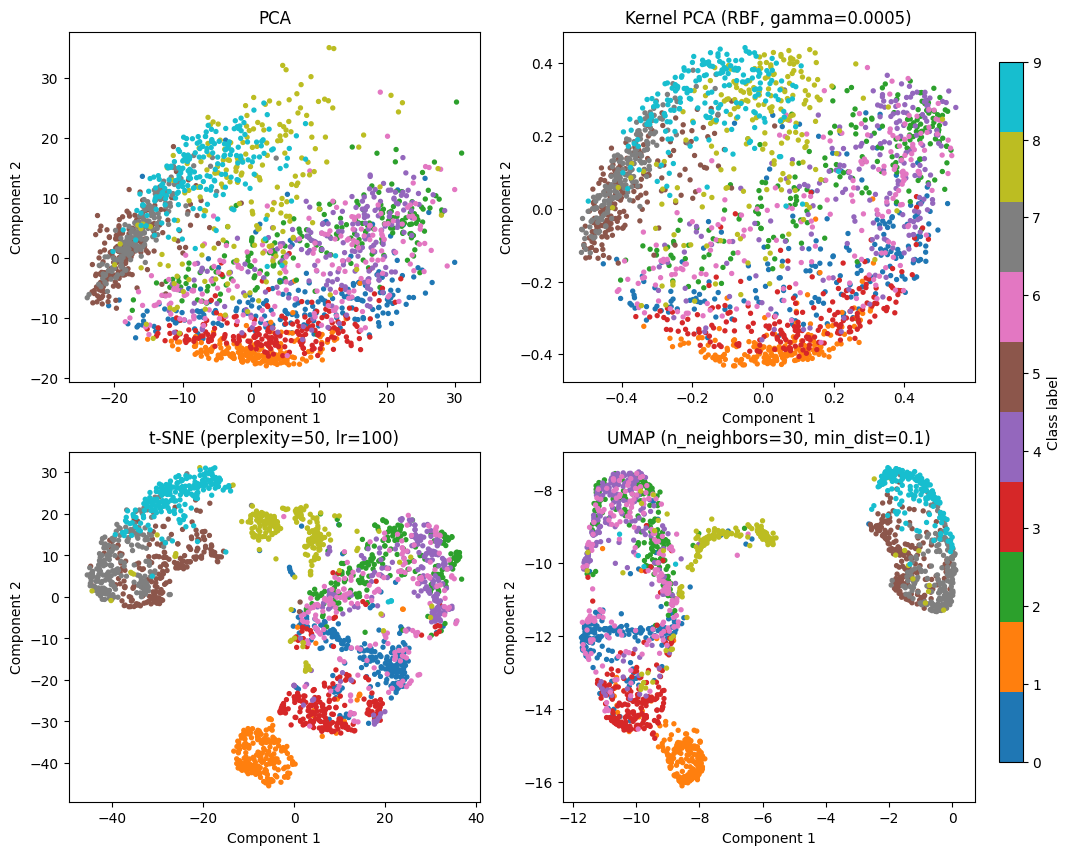

Saved final comparison figure to figs_results/a6_task1_fig03_senthilnathan_t_final_best_2x2.png


In [10]:
# Review the saved figures and then fill in the two labels below.
# Examples: "perp_30_lr_500" and "nn_30_md_0p6"
best_tsne_label = "perp_50_lr_100"
best_umap_label = "nn_30_md_0p1"

if best_tsne_label is None or best_umap_label is None:
    raise ValueError("Set best_tsne_label and best_umap_label after reviewing the visuals.")

best_tsne = tsne_embeddings[best_tsne_label]
best_umap = umap_embeddings[best_umap_label]
best_tsne_params = tsne_label_to_params[best_tsne_label]
best_umap_params = umap_label_to_params[best_umap_label]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plots = [
    (Z_pca, "PCA"),
    (Z_kpca, "Kernel PCA (RBF, gamma=0.0005)"),
    (best_tsne, f"t-SNE (perplexity={best_tsne_params['perplexity']}, lr={best_tsne_params['learning_rate']})"),
    (best_umap, f"UMAP (n_neighbors={best_umap_params['n_neighbors']}, min_dist={best_umap_params['min_dist']})"),
]

for ax, (Z, title) in zip(axes.ravel(), plots):
    sc = ax.scatter(Z[:, 0], Z[:, 1], c=y, cmap="tab10", s=8)
    ax.set_title(title)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")

fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.9, 0.15, 0.02, 0.7])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label("Class label")
final_panel_path = next_figure_path("final_best_2x2")
fig.savefig(final_panel_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved final comparison figure to {final_panel_path}")

In [11]:
# Run this after setting best_tsne_label and best_umap_label.

def run_pca_pipeline():
    scaler_local = StandardScaler()
    X_scaled_local = scaler_local.fit_transform(X)
    return PCA(n_components=2).fit_transform(X_scaled_local)


def run_kpca_pipeline():
    scaler_local = StandardScaler()
    X_scaled_local = scaler_local.fit_transform(X)
    return KernelPCA(n_components=2, kernel="rbf", gamma=0.0005).fit_transform(X_scaled_local)


def run_tsne_pipeline():
    scaler_local = StandardScaler()
    X_scaled_local = scaler_local.fit_transform(X)
    X_pca50_local = PCA(n_components=50).fit_transform(X_scaled_local)
    params = tsne_label_to_params[best_tsne_label]
    return TSNE(
        n_components=2,
        perplexity=params["perplexity"],
        init="pca",
        learning_rate=params["learning_rate"],
        random_state=0,
    ).fit_transform(X_pca50_local)


def run_umap_pipeline():
    scaler_local = StandardScaler()
    X_scaled_local = scaler_local.fit_transform(X)
    X_pca50_local = PCA(n_components=50).fit_transform(X_scaled_local)
    params = umap_label_to_params[best_umap_label]
    return umap.UMAP(
        n_components=2,
        n_neighbors=params["n_neighbors"],
        min_dist=params["min_dist"],
        random_state=0,
    ).fit_transform(X_pca50_local)


runtime_rows = []
for method_name, runner in [
    ("PCA", run_pca_pipeline),
    ("Kernel PCA", run_kpca_pipeline),
    ("t-SNE", run_tsne_pipeline),
    ("UMAP", run_umap_pipeline),
]:
    _, times = timed_run(runner, repeats=3)
    runtime_rows.append({
        "method": method_name,
        "times_seconds": times,
        "mean_seconds": np.mean(times),
        "std_seconds": np.std(times),
    })

runtime_df = pd.DataFrame(runtime_rows).sort_values("mean_seconds")
fastest = runtime_df.iloc[0]["mean_seconds"]
runtime_df["relative_to_fastest"] = runtime_df["mean_seconds"] / fastest
runtime_df

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,method,times_seconds,mean_seconds,std_seconds,relative_to_fastest
0,PCA,"[0.05751441699976567, 0.044318500000372296, 0....",0.047983,0.006799,1.000000
1,Kernel PCA,"[0.17965937500048312, 0.1669478749990958, 0.17...",0.174966,0.005697,3.646417
2,t-SNE,"[6.781082958999832, 6.4252316660004, 6.8067307...",6.671015,0.174110,139.028720
3,UMAP,"[17.767358249999234, 17.783807791000072, 17.74...",17.764197,0.017446,370.218562
